# Feature Engineering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
%matplotlib inline

In [2]:
df_all = pd.read_csv('./data/df_all.csv')
df_all.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S


In [3]:
def divide_df(all_data):
    return all_data.loc[:890].copy(), all_data.loc[891:].drop(['Survived'], axis=1).copy()

df_train, df_test = divide_df(df_all)

In [4]:
def get_title(name):
    title_search = re.search(' ([A-Za-z]+)\.', name)
    if title_search:
        return title_search.group(1)
    return ''
df_all['Title'] = df_all.Name.apply(get_title)
df_train['Title'] = df_train.Name.apply(get_title)
df_all.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Mr
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Miss
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Mr


In [5]:
df_train.Title.value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

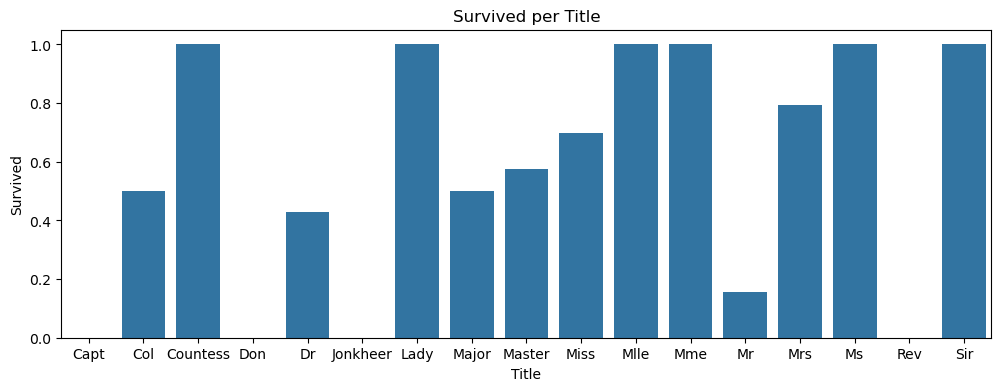

In [6]:
tt_sur_mean = df_train.groupby('Title')['Survived'].mean().reset_index()
plt.figure(figsize=(12,4))
sns.barplot(x = 'Title', y = 'Survived', data = tt_sur_mean)
plt.title('Survived per Title')
plt.show()

In [7]:
rare_map = list(df_all.Title.value_counts().keys())[4:]
df_all.Title = df_all.Title.replace(rare_map, 'Rare')

In [8]:
df_all['FamilySize'] = df_all['SibSp'] + df_all['Parch'] + 1
df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch'] + 1
df_all['FamilySize'].value_counts()

FamilySize
1     790
2     235
3     159
4      43
6      25
5      22
7      16
11     11
8       8
Name: count, dtype: int64

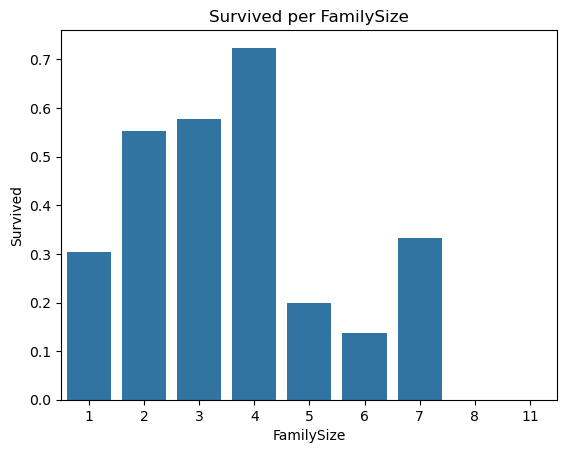

In [9]:
fs_sur_mean = df_train.groupby('FamilySize')['Survived'].mean().reset_index()
plt.figure()
sns.barplot(x='FamilySize', y='Survived', data=fs_sur_mean)
plt.title('Survived per FamilySize')
plt.show()

In [10]:
bins = [0, 1, 4, 12]
labels = ['Single', 'Small', 'Big']

df_all['FamilyCategory'] = pd.cut(
    df_all['FamilySize'], 
    bins=bins, 
    labels=labels, 
    right=True,
    include_lowest=True
)

df_all.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,FamilyCategory
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Mr,2,Small
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,2,Small
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Miss,1,Single
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,2,Small
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Mr,1,Single


In [11]:
df_all['FamilyCategory'].value_counts()

FamilyCategory
Single    790
Small     437
Big        82
Name: count, dtype: int64

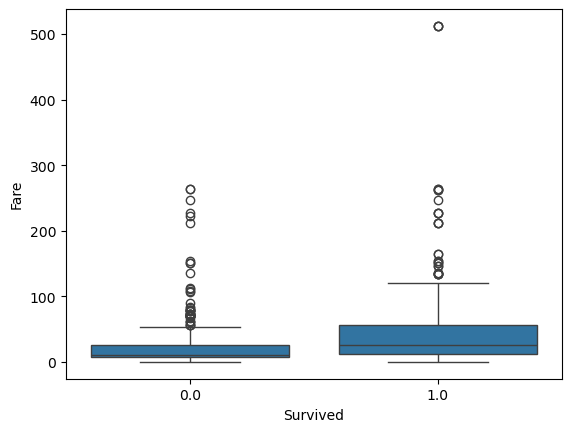

In [12]:
plt.figure()
sns.boxplot(x = 'Survived', y = 'Fare', data = df_train)
plt.show()

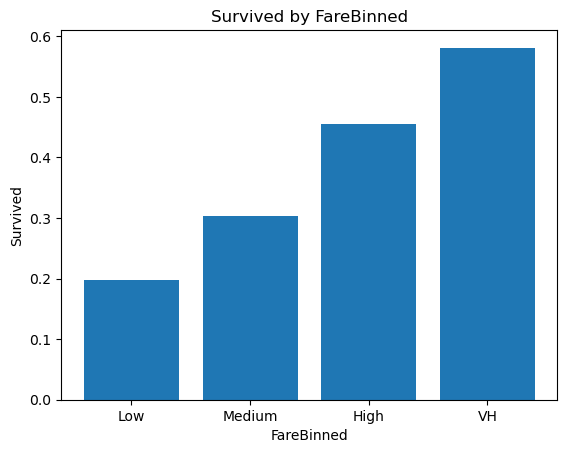

In [13]:
bins = df_train['Fare'].quantile([0, 0.25, 0.5, 0.75, 1]).tolist()
labels = ['Low', 'Medium', 'High', 'VH']
df_all['FareBinned'] = pd.cut(
    df_all['Fare'],
    bins = bins,
    labels = labels,
    include_lowest = True,
    right = True
)
fare_mean = df_all.groupby('FareBinned', observed=True)['Survived'].mean().reset_index()
plt.figure()
plt.bar(fare_mean['FareBinned'], fare_mean['Survived'])
plt.title('Survived by FareBinned')
plt.xlabel('FareBinned')
plt.ylabel('Survived')
plt.show()

In [14]:
df_all.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,FamilyCategory,FareBinned
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Mr,2,Small,Low
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,2,Small,VH
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Miss,1,Single,Medium
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,2,Small,VH
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Mr,1,Single,Medium


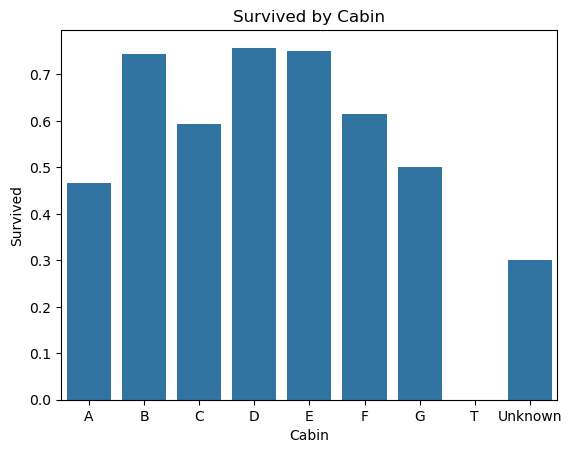

In [15]:
cabin_mean = df_train.groupby('Cabin', observed = True)['Survived'].mean().reset_index()
plt.figure()
sns.barplot(x = 'Cabin', y = 'Survived', data = cabin_mean)
plt.title('Survived by Cabin')
plt.show()

In [16]:
def map_cabin_group(c):
    if c in ['B', 'D', 'E']:
        return 'HighDeck'
    elif c in ['A', 'C', 'F', 'G']:
        return 'MidDeck'
    else:
        return 'Unknown'
        
df_all['CabinGroup'] = df_all['Cabin'].map(map_cabin_group)

In [17]:
bins = [0, 16, 60, 81] 
labels = ['Child', 'Adult', 'Elderly']
df_all['AgeGroup'] = pd.cut(
    df_all['Age'],
    bins = bins,
    labels = labels,
    right = True,
    include_lowest = True
)
df_all['AgeGroup'].value_counts()

AgeGroup
Adult      1142
Child       134
Elderly      33
Name: count, dtype: int64

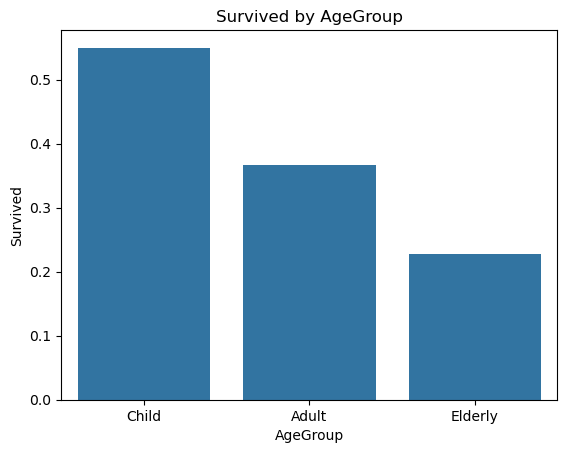

In [18]:
ag_mean = df_all.groupby('AgeGroup', observed = True)['Survived'].mean().reset_index()
plt.figure()
sns.barplot(x = 'AgeGroup', y = 'Survived', data = ag_mean)
plt.title('Survived by AgeGroup')
plt.show()

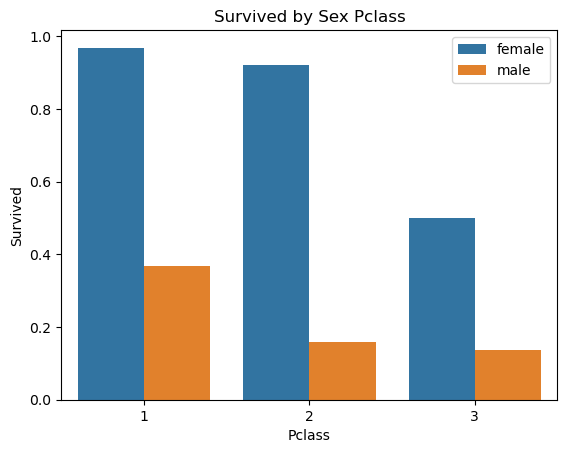

In [19]:
sex_pcl_mean = df_train.groupby(['Sex', 'Pclass'])['Survived'].mean().reset_index()
plt.figure()
sns.barplot(x = 'Pclass', y = 'Survived', hue = 'Sex', data = sex_pcl_mean)
plt.title('Survived by Sex Pclass')
plt.legend()
plt.show()

In [20]:
df_all['Sex_Pclass'] = df_all['Sex'].astype(str) + '_' + df_all['Pclass'].astype(str)
df_all.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,FamilyCategory,FareBinned,CabinGroup,AgeGroup,Sex_Pclass
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Mr,2,Small,Low,Unknown,Adult,male_3
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,2,Small,VH,MidDeck,Adult,female_1
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Miss,1,Single,Medium,Unknown,Adult,female_3
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,2,Small,VH,MidDeck,Adult,female_1
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Mr,1,Single,Medium,Unknown,Adult,male_3


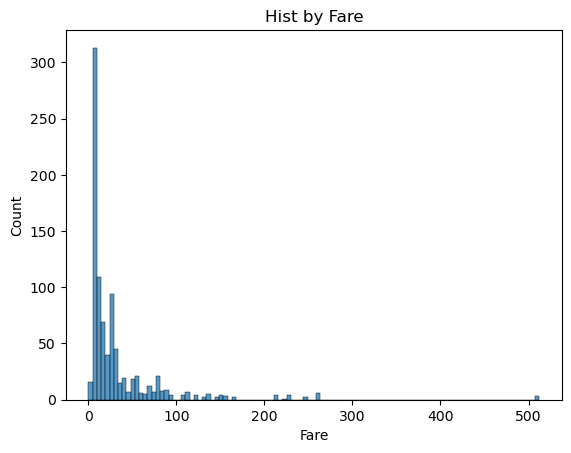

In [21]:
plt.figure()
sns.histplot(df_train['Fare'])
plt.title('Hist by Fare')
plt.show()

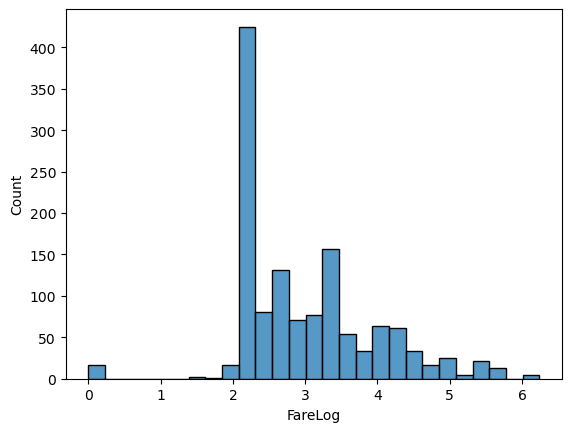

In [22]:
df_all['FareLog'] = np.log1p(df_all['Fare'])
plt.figure()
sns.histplot(df_all['FareLog'])
plt.show()

In [23]:
df_all['Age*Pclass'] = df_all['Age'] * df_all['Pclass']

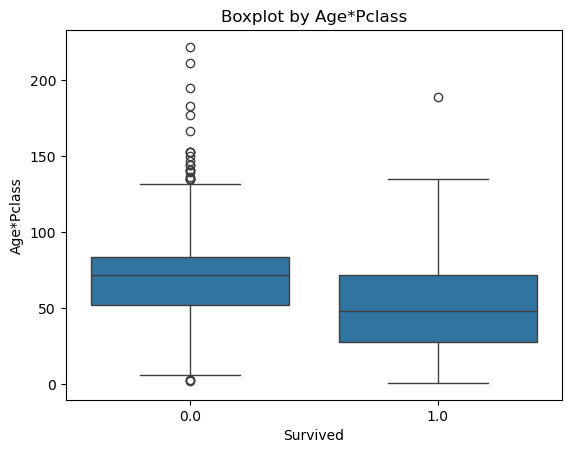

In [24]:
plt.figure()
sns.boxplot(x = df_all['Survived'], y = df_all['Age*Pclass'])
plt.title('Boxplot by Age*Pclass')
plt.show()

In [25]:
df_all['FarePerPerson'] = df_all['Fare'] / df_all['FamilySize']

In [26]:
ticket_counts = df_all['Ticket'].value_counts()
df_all['TicketFrequency'] = df_all['Ticket'].map(ticket_counts)
df_all.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,FamilySize,FamilyCategory,FareBinned,CabinGroup,AgeGroup,Sex_Pclass,FareLog,Age*Pclass,FarePerPerson,TicketFrequency
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,2,Small,Low,Unknown,Adult,male_3,2.110213,66.0,3.62500,1
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,2,Small,VH,MidDeck,Adult,female_1,4.280593,38.0,35.64165,2
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,1,Single,Medium,Unknown,Adult,female_3,2.188856,78.0,7.92500,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,2,Small,VH,MidDeck,Adult,female_1,3.990834,35.0,26.55000,2
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,1,Single,Medium,Unknown,Adult,male_3,2.202765,105.0,8.05000,1


In [27]:
def extract_surname(names):
    families = []
    for name in names:
        family = name.split(',')[0].strip()
        family = family.translate(str.maketrans('', '', string.punctuation))
        families.append(family)
    return families
    
df_all['Family'] = extract_surname(df_all['Name'])

In [28]:
df_train, df_test = divide_df(df_all)

survival_rate_mean = df_train['Survived'].mean()

common_families = set(df_train['Family']).intersection(df_test['Family'])
common_tickets  = set(df_train['Ticket']).intersection(df_test['Ticket'])

In [29]:
df_family_rate = df_train.groupby('Family')[['Survived', 'FamilySize']].median().reset_index()
df_ticket_rate = df_train.groupby('Ticket')[['Survived', 'TicketFrequency']].median().reset_index()

family_rates = df_family_rate[
    (df_family_rate['FamilySize'] > 1) &
    (df_family_rate['Family'].isin(common_families))
][['Family', 'Survived']].set_index('Family')['Survived'].to_dict()

ticket_rates = df_ticket_rate[
    (df_ticket_rate['TicketFrequency'] > 1) &
    (df_ticket_rate['Ticket'].isin(common_tickets))
][['Ticket', 'Survived']].set_index('Ticket')['Survived'].to_dict()

def add_group_rate_features(df, family_rates, ticket_rates, survival_rate_mean):
    df = df.copy()
    df['FamilySurvivalRate'] = df['Family'].map(family_rates).fillna(survival_rate_mean)
    df['FamilySurvivalRateNA'] = df['Family'].isin(family_rates).astype(int)
    df['TicketSurvivalRate'] = df['Ticket'].map(ticket_rates).fillna(survival_rate_mean)
    df['TicketSurvivalRateNA'] = df['Ticket'].isin(ticket_rates).astype(int)
    return df

df_train = add_group_rate_features(df_train, family_rates, ticket_rates, survival_rate_mean)
df_test  = add_group_rate_features(df_test,  family_rates, ticket_rates, survival_rate_mean)

for df in [df_train, df_test]:
    df['SurvivalRate'] = (df['TicketSurvivalRate'] + df['FamilySurvivalRate']) / 2
    df['SurvivalRateNA'] = (df['TicketSurvivalRateNA'] + df['FamilySurvivalRateNA']) / 2 

In [30]:
df_train['Survived'] = df_train['Survived'].astype(int)

In [31]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Age*Pclass,FarePerPerson,TicketFrequency,Family,FamilySurvivalRate,FamilySurvivalRateNA,TicketSurvivalRate,TicketSurvivalRateNA,SurvivalRate,SurvivalRateNA
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,66.0,3.62500,1,Braund,0.383838,0,0.383838,0,0.383838,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,38.0,35.64165,2,Cumings,1.000000,1,1.000000,1,1.000000,1.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,78.0,7.92500,1,Heikkinen,0.383838,0,0.383838,0,0.383838,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,35.0,26.55000,2,Futrelle,0.383838,0,0.383838,0,0.383838,0.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,105.0,8.05000,1,Allen,0.383838,0,0.383838,0,0.383838,0.0


In [32]:
df_train.to_csv('./data/train_fe.csv', index = False)
df_test.to_csv('./data/test_fe.csv', index = False)